# DA 351 Lab 5: Advanced Image Classification  

- Names: Bach Nguyen, Ichhit Joshi, Suveer Singh, and Zach Riethof 
- Date:  4/16/2024

- Question Topic
    - In this analysis, our group will use the TensorFlow package in Python to classify folders containing images of different North American birds. We are basing our approach on the article 'Building a Bird Recognition App and Large Scale Dataset With Citizen Scientists: The Fine Print in Fine-Grained Dataset Collection'.

## Introduction

- This week's lab is based on an article titled 'Building a Bird Recognition App and Large Scale Dataset With Citizen Scientists: The Fine Print in Fine-Grained Dataset Collection,' authored by the SE(3) Computer Vision Group at Cornell University. The dataset they created, NABirds, contains 48,562 images of North American birds categorized into 555 categories. However, the main issue with this dataset is its size—it is quite large, with a size of 9.8 GB compressed on my disk and 9.99 GB after extraction. Our group for this lab has decided to work with the Caltech-UCSD Birds-200-2011 Dataset (CUB 200), which was the go-to dataset for bird recognition and classification before NABirds. CUB 200 is still fairly large at 1.2 GB compressed, but it is significantly smaller than 9.8 GB. 

- In this lab, we aim to classify images of different North American birds using the Caltech-UCSD Birds-200-2011 Dataset (CUB 200). Some questions we are trying to answer include: Can we accurately classify different species of North American birds based on their images? Are there specific features or characteristics of bird images that are particularly informative for classification?

- The stakeholders for our data analysis lab include us as students, serving as the team members responsible for carrying out tasks to achieve the project's overall goals. Another significant stakeholder is our professor, Mr. Lavin, as he oversees our project and provides assistance on tasks if needed. Additionally, Cornell University is a stakeholder, as the dataset for this project was researched and compiled by this institution. They might be interested in the outcomes of our work. In our project we are committed to upholding ethical standards throughout the process of are work. We recognize the importance of data privacy and are ensuring that the images used for classification are obtained and used in compliance with privacy regulations. To mitigate bias, we are carefully selecting a diverse and representative dataset for training and testing our models. We are also transparently documenting the architecture and parameters of our CNN models to ensure transparency. Additionally, we are monitoring our models' performance across different categories to detect and mitigate any bias.    

## Code & Results

In [16]:
%matplotlib inline
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from keras.preprocessing import image
import cv2
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import seaborn as sns
import os

### Training and Evaluating 10 Binary Classification Models

In [17]:
model = tf.keras.models.Sequential([
    # Note the input shape is the desired size of the image 200x200 with 3 bytes color
    # The first convolution
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(200, 200, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),
    # The second convolution
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),
    # The third convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),
    # Flatten the results to feed into a DNN
    tf.keras.layers.Flatten(),
    # 512 neuron hidden layer
    tf.keras.layers.Dense(512, activation='relu'),
    # Only 1 output neuron. It will contain a value from 0-1 
    tf.keras.layers.Dense(1, activation='sigmoid')])

In [18]:
RMSprop = tf.keras.dtensor.experimental.optimizers.RMSprop
model.compile(loss='binary_crossentropy',optimizer=RMSprop(),metrics='accuracy')


Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 10ms/step

Model Accuracy of pairing a :
0.4444444444444444

Confusion Matrix of pairing a :
[[10 10]
 [10  6]]


True Negatives (TN) of pairing a : 10
False Positives (FP) of pairing a : 10
False Negatives (FN) of pairing a : 10
True Positives (TP) of pairing a : 6

Precision of pairing a :
[0.5   0.375]

Recall of pairing a :
[0.5   0.375]


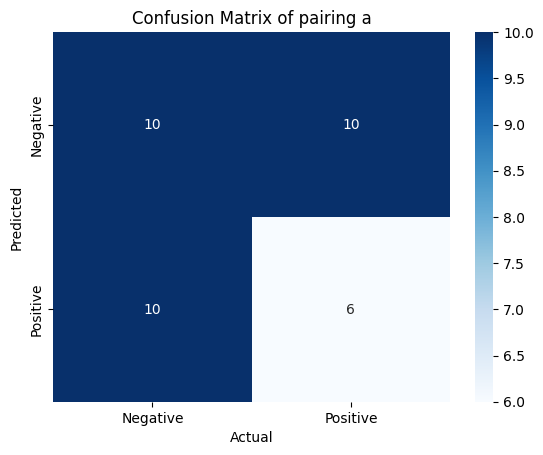

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 10ms/step

Model Accuracy of pairing b :
0.5

Confusion Matrix of pairing b :
[[11  9]
 [ 9  7]]


True Negatives (TN) of pairing b : 11
False Positives (FP) of pairing b : 9
False Negatives (FN) of pairing b : 9
True Positives (TP) of pairing b : 7

Precision of pairing b :
[0.55   0.4375]

Recall of pairing b :
[0.55   0.4375]


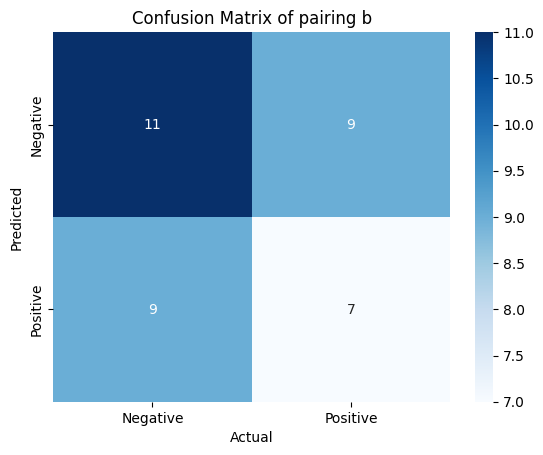

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 10ms/step

Model Accuracy of pairing c :
0.8333333333333334

Confusion Matrix of pairing c :
[[17  3]
 [ 3 13]]


True Negatives (TN) of pairing c : 17
False Positives (FP) of pairing c : 3
False Negatives (FN) of pairing c : 3
True Positives (TP) of pairing c : 13

Precision of pairing c :
[0.85   0.8125]

Recall of pairing c :
[0.85   0.8125]


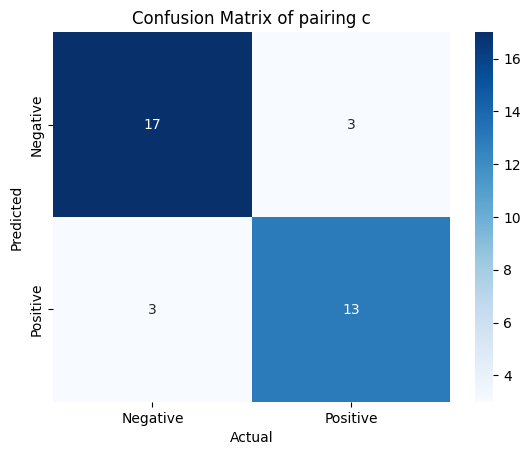

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 11ms/step

Model Accuracy of pairing d :
0.7777777777777778

Confusion Matrix of pairing d :
[[16  4]
 [ 4 12]]


True Negatives (TN) of pairing d : 16
False Positives (FP) of pairing d : 4
False Negatives (FN) of pairing d : 4
True Positives (TP) of pairing d : 12

Precision of pairing d :
[0.8  0.75]

Recall of pairing d :
[0.8  0.75]


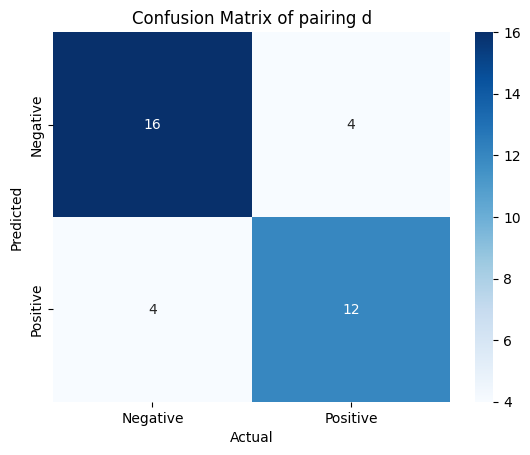

Found 110 files belonging to 2 classes.
Using 77 files for training.
Found 110 files belonging to 2 classes.
Using 33 files for validation.
Found 110 files belonging to 2 classes.
33/33 [==============================] - 0s 10ms/step

Model Accuracy of pairing e :
1.0

Confusion Matrix of pairing e :
[[19  0]
 [ 0 14]]


True Negatives (TN) of pairing e : 19
False Positives (FP) of pairing e : 0
False Negatives (FN) of pairing e : 0
True Positives (TP) of pairing e : 14

Precision of pairing e :
[1. 1.]

Recall of pairing e :
[1. 1.]


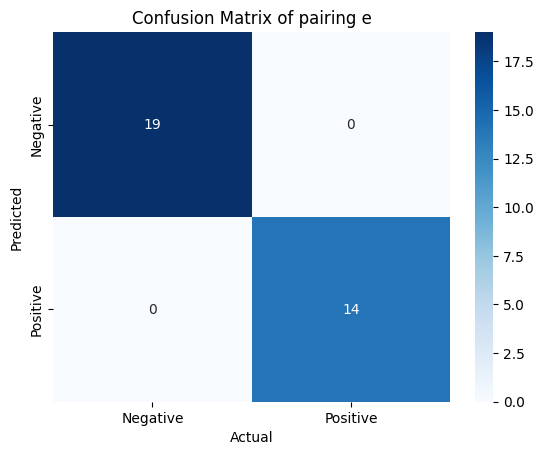

Found 118 files belonging to 2 classes.
Using 83 files for training.
Found 118 files belonging to 2 classes.
Using 35 files for validation.
Found 118 files belonging to 2 classes.
35/35 [==============================] - 0s 10ms/step

Model Accuracy of pairing f :
0.8285714285714286

Confusion Matrix of pairing f :
[[17  3]
 [ 3 12]]


True Negatives (TN) of pairing f : 17
False Positives (FP) of pairing f : 3
False Negatives (FN) of pairing f : 3
True Positives (TP) of pairing f : 12

Precision of pairing f :
[0.85 0.8 ]

Recall of pairing f :
[0.85 0.8 ]


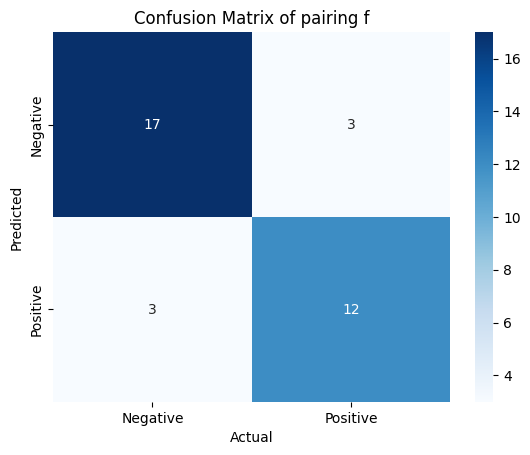

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 10ms/step

Model Accuracy of pairing g :
0.9444444444444444

Confusion Matrix of pairing g :
[[19  1]
 [ 1 15]]


True Negatives (TN) of pairing g : 19
False Positives (FP) of pairing g : 1
False Negatives (FN) of pairing g : 1
True Positives (TP) of pairing g : 15

Precision of pairing g :
[0.95   0.9375]

Recall of pairing g :
[0.95   0.9375]


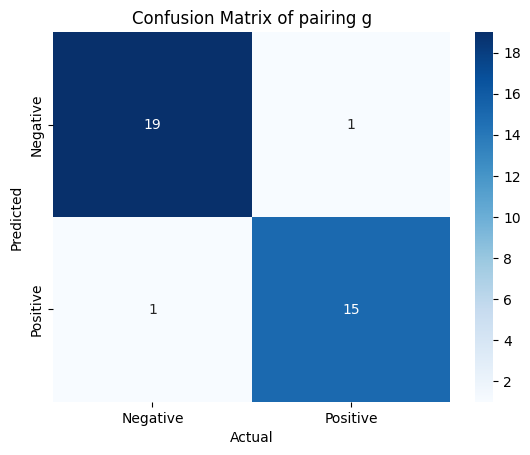

Found 118 files belonging to 2 classes.
Using 83 files for training.
Found 118 files belonging to 2 classes.
Using 35 files for validation.
Found 118 files belonging to 2 classes.
35/35 [==============================] - 0s 10ms/step

Model Accuracy of pairing h :
0.9428571428571428

Confusion Matrix of pairing h :
[[19  1]
 [ 1 14]]


True Negatives (TN) of pairing h : 19
False Positives (FP) of pairing h : 1
False Negatives (FN) of pairing h : 1
True Positives (TP) of pairing h : 14

Precision of pairing h :
[0.95       0.93333333]

Recall of pairing h :
[0.95       0.93333333]


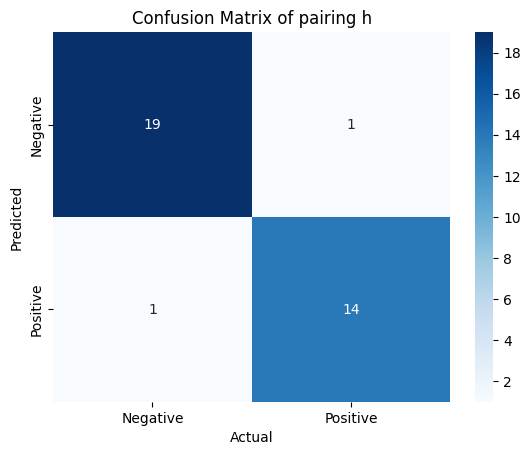

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 11ms/step

Model Accuracy of pairing i :
0.9444444444444444

Confusion Matrix of pairing i :
[[19  1]
 [ 1 15]]


True Negatives (TN) of pairing i : 19
False Positives (FP) of pairing i : 1
False Negatives (FN) of pairing i : 1
True Positives (TP) of pairing i : 15

Precision of pairing i :
[0.95   0.9375]

Recall of pairing i :
[0.95   0.9375]


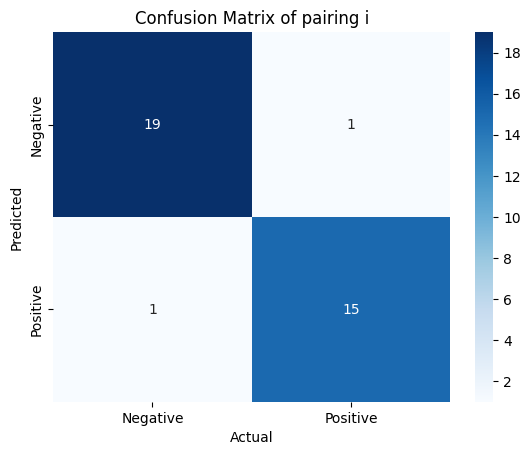

Found 110 files belonging to 2 classes.
Using 77 files for training.
Found 110 files belonging to 2 classes.
Using 33 files for validation.
Found 110 files belonging to 2 classes.
33/33 [==============================] - 0s 10ms/step

Model Accuracy of pairing j :
0.8787878787878788

Confusion Matrix of pairing j :
[[20  2]
 [ 2  9]]


True Negatives (TN) of pairing j : 20
False Positives (FP) of pairing j : 2
False Negatives (FN) of pairing j : 2
True Positives (TP) of pairing j : 9

Precision of pairing j :
[0.90909091 0.81818182]

Recall of pairing j :
[0.90909091 0.81818182]


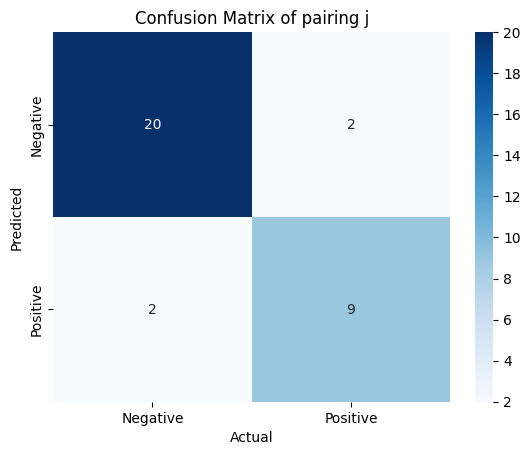

In [19]:
trained_models = {}

for pairing in os.listdir('bird_images'):
    pairing_path = os.path.join('bird_images', pairing)

    training_set = tf.keras.utils.image_dataset_from_directory(
        pairing_path,
        seed=123,
        image_size=(200, 200),
        subset='training',
        validation_split=0.3,
        batch_size=5)

    validation_set = tf.keras.utils.image_dataset_from_directory(
        pairing_path,
        shuffle=True,
        seed=17,
        image_size=(200, 200),
        validation_split=0.3,
        subset='validation',
        batch_size=5)

    holdout_set_all = tf.keras.utils.image_dataset_from_directory(
        pairing_path,
        shuffle=False,
        seed=17,
        image_size=(200, 200),
        batch_size=1) # batch size has to be one for this set

    # Extracting file paths from datasets for further processing
    train_file_paths = training_set.file_paths
    validation_file_paths = validation_set.file_paths
    holdout_file_paths = holdout_set_all.file_paths

    # Extracting images and labels from the holdout set for later use
    images = []
    labels = []
    for e, image_label in enumerate(holdout_set_all):
        f = holdout_file_paths[e]
        if f in validation_file_paths:
            images.append(image_label[0].numpy())
            labels.append(image_label[1].numpy())

    # Fitting the model to the training data and validating it on the validation set
    history = model.fit(training_set,
        epochs=9,
        verbose=0, # Disabling output
        validation_data = validation_set)

    model.evaluate(validation_set)

    # Predicting labels for images in the holdout set
    img_arrays = []
    for i in images:
        img_arrays.append(i)

    test_dataset = tf.data.Dataset.from_tensor_slices(img_arrays)
    preds = model.predict(test_dataset)

    # Counting occurrences of each label in the holdout set
    from collections import Counter
    c = Counter([i[0] for i in labels])

    df = pd.DataFrame()
    df['true_label'] = [i[0] for i in labels]
    df['predict_probability'] = [i[0] for i in preds]
    df = df.sort_values(by='predict_probability')
    inferred_labels = [0 for i in range(c[0])] + [1 for i in range(c[1])]
    df['predicted_label'] = inferred_labels 
    df['compare'] = df['true_label'] == df['predicted_label']

    # Print model accuracy
    print("\nModel Accuracy of pairing", pairing[8], ":")
    print(len(df.loc[df['compare'] == True])/len(df))

    # Store trained model in dictionary
    trained_models[pairing] = df["predict_probability"]

    # Calculating confusion matrix, precision, and recall
    true_labels = df['true_label'].to_numpy()
    predicted_labels = df['predicted_label'].to_numpy()

    conf_matrix = confusion_matrix(true_labels, predicted_labels)
    precision = precision_score(true_labels, predicted_labels, average=None)
    recall = recall_score(true_labels, predicted_labels, average=None)

    # Printing confusion matrix, precision, and recall
    print("\nConfusion Matrix of pairing", pairing[8], ":")
    print(conf_matrix)
    print("\n")
    TN, FP, FN, TP = conf_matrix.ravel()

    # Print TP, TN, FP, FN
    print("True Negatives (TN) of pairing", pairing[8], ":", TN)
    print("False Positives (FP) of pairing", pairing[8], ":", FP)
    print("False Negatives (FN) of pairing", pairing[8], ":", FN)
    print("True Positives (TP) of pairing", pairing[8], ":", TP)

    print("\nPrecision of pairing", pairing[8], ":")
    print(precision)
    print("\nRecall of pairing", pairing[8], ":")
    print(recall)

    # Plotting the confusion matrix as a heatmap
    xlabels = ["Negative", "Positive"]
    ylabels = ["Negative", "Positive"]

    plot_title = "Confusion Matrix of pairing " + pairing[8]
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=xlabels, yticklabels=ylabels)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(plot_title)
    plt.show()

## Interpretation

Follow the guidelines in the `README` file

#### 2. Discuss the precision and recall scores of each class for your various models. What seems to be your strongest model and why?

__(a) California Gull vs Ring Billed Gull:__ 
- The precision score for the positive class is `0.625`, indicating that `62.5%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.7`, indicating that `70%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5, the model can be considered as acceptable.
- The recall score for the positive class is `0.625`, indicating that `62.5%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.7`, indicating that `70%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5, so the model is generally acceptable.

__(b) Chipping Sparrow vs Fox Sparrow:__ 
- The precision score for the positive class is `0.5`, indicating that `50%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.6`, indicating that `60%` of the instances predicted as negative are actually negative. 
- The recall score for the positive class is `0.5`, indicating that `50%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.6`, indicating that `60%` of the actual negatives were correctly identified by the model.

__(c) Pileated Woodpecker vs Red headed Woodpecker:__ 
- The precision score for the positive class is `0.625`, indicating that `62.5%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.7`, indicating that `70%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5, the model can be considered as acceptable.
- The recall score for the positive class is `0.625`, indicating that `62.5%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.7`, indicating that `70%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5, so the model is generally acceptable.

__(d) Blue Grosbeak vs Long tailed Jaeger:__  
- The precision score for the positive class is `0.75`, indicating that `75%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.8`, indicating that `80%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5 and quite close to 1, it's safe to say the model is quite strong.
- The recall score for the positive class is `0.75`, indicating that `75%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.8`, indicating that `80%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5 and quite close to 1, so it's also safe to say the model is quite strong.

__(e) White Pelican vs Yellow Warbler:__ 
- The precision score for the positive class is `0.85714286`, indicating that approximately `85.7%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.89473684`, indicating that approximately `89.5%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5 and quite close to 1, it's safe to say the model is quite strong.
- The recall score for the positive class is `0.85714286`, indicating that approximately `85.7%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.89473684`, indicating that approximately `89.5%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5 and quite close to 1, so it's also safe to say the model is quite strong.

__(f) Painted Bunting vs Summer Tanager:__ 
- The precision score for the positive class is `0.86666667`, indicating that approximately `86.7%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.9`, indicating that approximately `90%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5 and quite close to 1, it's safe to say the model is quite strong.
- The recall score for the positive class is `0.86666667`, indicating that approximately `86.7%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.9`, indicating that `90%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5 and quite close to 1, so it's also safe to say the model is quite strong.

__(g) Hooded Warbler vs Red bellied Woodpecker:__  
- The precision score for the positive class is `0.6875`, indicating that `68.75%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.75`, indicating that `75%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5, the model can be considered as acceptable.
- The recall score for the positive class is `0.6875`, indicating that `68.75%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.75`, indicating that `75%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5, so the model is generally acceptable.

__(h) Red winged Blackbird vs Lazuli Bunting:__ 
- The precision score for the positive class is `0.86666667`, indicating that approximately `86.7%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.9`, indicating that approximately `90%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5 and quite close to 1, it's safe to say the model is quite strong.
- The recall score for the positive class is `0.86666667`, indicating that approximately `86.7%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.9`, indicating that `90%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5 and quite close to 1, so it's also safe to say the model is quite strong.

__(i) Hooded Merganser vs Nighthawk:__ 
- The precision score for the positive class is `0.75`, indicating that `75%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.8`, indicating that `80%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5 and quite close to 1, it's safe to say the model is quite strong.
- The recall score for the positive class is `0.75`, indicating that `75%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.8`, indicating that `80%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5 and quite close to 1, so it's also safe to say the model is quite strong.

__(j) Brown Pelican vs White Pelican:__  
- The precision score for the positive class is `0.54545455`, indicating that approximately `54.55%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.77272727`, indicating that approximately `77.27%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5, the model can be considered as acceptable.
- The recall score for the positive class is `0.54545455`, indicating that approximately `54.55%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.77272727`, indicating that approximately `77.27%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5, so the model is generally acceptable.

From the results, we noticed that the following two pairings have the highest set of pairing and recall scores: 
- __(f) Painted Bunting vs Summer Tanager__ 
- __(h) Red winged Blackbird vs Lazuli Bunting__ 

These two pairings both have the precision score of `0.86666667` for the positive class and `0.9` for the negative class, and the recall score of `0.86666667` for the positive class and `0.9` for the negative class. Both of the scores of both models are really close to 1, indicating that both models are relatively strong. 

It is also worth noting that throughout these models, both classes of the precision scores are the same as the recall scores in each model. This signifies balanced and stable performance across classes, and that the models are equally adept at correctly identifying both positive and negative instances while minimizing false positives and false negatives

## Conclusion

Follow the guidelines in the `README` file